In [5]:
!pip install vnstock

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 2.0 MB/s eta 0:00:00


In [6]:
from vnstock import Quote
import pandas as pd
import time
import os

# 1. The list of the 30 individual stocks
vn30_tickers = [
    "ACB", "BCM", "BID", "BVH", "CTG", "FPT", "GAS", "GVR", "HDB", "HPG",
    "MBB", "MSN", "MWG", "PLX", "POW", "SAB", "SHB", "SSB", "SSI", "STB",
    "TCB", "TPB", "VCB", "VHM", "VIB", "VIC", "VJC", "VNM", "VPB", "VRE"
]

# Optional: Create a directory to keep your workspace clean
output_folder = "VN30_Raw_Data"
os.makedirs(output_folder, exist_ok=True)

print(f"Starting crawl for {len(vn30_tickers)} stocks...")

# 2. Loop through each ticker
for ticker in vn30_tickers:
    print(f"Fetching data for {ticker}...")
    
    try:
        # Initialize the fetcher for the specific ticker
        quote = Quote(symbol=ticker, source="KBS") 
        
        # Fetch the history
        df = quote.history(
            start="2023-01-01", 
            end="2026-02-28", 
            interval="1D"
        )
        
        # Check if the dataframe is empty (sometimes APIs fail or stocks are halted)
        if not df.empty:
            # Sort chronologically to prevent future data leaking into past data
            df = df.sort_values("time").reset_index(drop=True)
            
            # Save the file with a dynamic name (e.g., FPT_price_2023_2026.csv)
            file_path = f"{output_folder}/{ticker}_price_2023_2026.csv"
            df.to_csv(file_path, index=False)
            print(f" -> Saved {ticker} successfully. ({len(df)} rows)")
        else:
            print(f" -> Warning: No data found for {ticker}.")
            
    except Exception as e:
        print(f" -> Error fetching {ticker}: {e}")
        
    # 3. CRITICAL: Pause for 1 second between requests
    # This prevents the KBS server from thinking you are launching a DDoS attack and blocking your IP.
    time.sleep(3.5)

print("Batch crawling complete!")

Starting crawl for 30 stocks...
Fetching data for ACB...
 -> Saved ACB successfully. (783 rows)
Fetching data for BCM...
 -> Saved BCM successfully. (783 rows)
Fetching data for BID...
 -> Saved BID successfully. (783 rows)
Fetching data for BVH...
 -> Saved BVH successfully. (783 rows)
Fetching data for CTG...
 -> Saved CTG successfully. (783 rows)
Fetching data for FPT...
 -> Saved FPT successfully. (783 rows)
Fetching data for GAS...
 -> Saved GAS successfully. (783 rows)
Fetching data for GVR...
 -> Saved GVR successfully. (783 rows)
Fetching data for HDB...
 -> Saved HDB successfully. (783 rows)
Fetching data for HPG...
 -> Saved HPG successfully. (783 rows)
Fetching data for MBB...
 -> Saved MBB successfully. (783 rows)
Fetching data for MSN...
 -> Saved MSN successfully. (783 rows)
Fetching data for MWG...
 -> Saved MWG successfully. (783 rows)
Fetching data for PLX...
 -> Saved PLX successfully. (783 rows)
Fetching data for POW...
 -> Saved POW successfully. (783 rows)
Fetching

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import os

# --- 1. Global Parameters ---
SEQ_LENGTH = 30
FEATURES = ['open', 'high', 'low', 'close', 'volume', 'EMA9', 'MA25', 'MA50']
VN30_TICKERS = [
    "ACB", "BCM", "BID", "BVH", "CTG", "FPT", "GAS", "GVR", "HDB", "HPG",
    "MBB", "MSN", "MWG", "PLX", "POW", "SAB", "SHB", "SSB", "SSI", "STB",
    "TCB", "TPB", "VCB", "VHM", "VIB", "VIC", "VJC", "VNM", "VPB", "VRE"
]

DATA_DIR = "/kaggle/working/VN30_Raw_Data"
PLOT_DIR = "/kaggle/working/VN30_Trend_Plots"

global_X_train, global_y_train = [], []
stock_test_data = {}

# --- 2. Data Processing: 3-Day Smoothed Target Returns ---
print(f"Looking for data inside: {DATA_DIR}")
print("Processing data and calculating 3-Day Smoothed Target Returns...")

for ticker in VN30_TICKERS:
    file_name = os.path.join(DATA_DIR, f"{ticker}_price_2023_2026.csv")
    if not os.path.exists(file_name):
        continue
        
    df = pd.read_csv(file_name)
    df['time'] = pd.to_datetime(df['time'])
    
    # Calculate Standard Input Indicators
    df['EMA9'] = df['close'].ewm(span=9, adjust=False).mean()
    df['MA25'] = df['close'].rolling(window=25).mean()
    df['MA50'] = df['close'].rolling(window=50).mean()
    
    # THE FIX: Calculate 3-Day Future Average Price
    df['Future_3D_Avg'] = df['close'].rolling(window=3).mean().shift(-3)
    df['Target_Return'] = (df['Future_3D_Avg'] - df['close']) / df['close']
    
    df_clean = df.dropna().reset_index(drop=True)
    
    # Scale inputs between 0 and 1
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_features = scaler.fit_transform(df_clean[FEATURES].values)
    
    # Extract raw target arrays
    target_returns = df_clean['Target_Return'].values
    current_close_prices = df_clean['close'].values
    future_avg_prices = df_clean['Future_3D_Avg'].values
    
    # Create Sequences
    xs, ys, last_prices, actual_future_targets = [], [], [], []
    for i in range(len(scaled_features) - SEQ_LENGTH):
        t = i + SEQ_LENGTH - 1
        xs.append(scaled_features[i:(t + 1)])
        ys.append(target_returns[t]) 
        last_prices.append(current_close_prices[t])
        actual_future_targets.append(future_avg_prices[t])
        
    X = np.array(xs)
    y = np.array(ys)
    last_prices = np.array(last_prices)
    actual_future_targets = np.array(actual_future_targets)
    
    # Split Train (80%) and Test (20%)
    split_idx = int(len(X) * 0.8)
    
    global_X_train.extend(X[:split_idx])
    global_y_train.extend(y[:split_idx])
    
    stock_test_data[ticker] = {
        'X_test': torch.tensor(X[split_idx:], dtype=torch.float32),
        'last_actual_prices': last_prices[split_idx:], 
        'actual_future_targets': actual_future_targets[split_idx:] 
    }

# Convert to PyTorch Tensors
X_train_tensor = torch.tensor(np.array(global_X_train), dtype=torch.float32)
y_train_tensor = torch.tensor(np.array(global_y_train), dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
print(f"Global Master Dataset created! Total training sequences: {len(X_train_tensor)}")

# --- 3. The Global Model ---
class GlobalTrendPredictor(nn.Module):
    def __init__(self, input_size=8, hidden_size=64, num_layers=2):
        super(GlobalTrendPredictor, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.linear(lstm_out[:, -1, :])

model = GlobalTrendPredictor()
criterion = nn.MSELoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- 4. Training Loop ---
epochs = 50 
print("Training the Global AI Model on 3-Day Trends...")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Global Loss (MSE of Returns): {total_loss/len(train_loader):.6f}")

# --- 5. Generate Plots by Reconstructing Prices ---
print(f"Generating 30 separate prediction plots inside {PLOT_DIR}...")
os.makedirs(PLOT_DIR, exist_ok=True)
model.eval()

with torch.no_grad():
    for ticker, data in stock_test_data.items():
        X_test = data['X_test']
        predicted_returns = model(X_test).numpy().flatten()
        
        # Predicted Future 3D Avg = Last Known Price * (1 + Predicted Return)
        last_known_prices = data['last_actual_prices']
        predicted_future_avg = last_known_prices * (1 + predicted_returns)
        actual_future_avg = data['actual_future_targets']
        
        plt.figure(figsize=(12, 6))
        plt.plot(actual_future_avg, label='Actual 3-Day Avg Price', color='blue')
        plt.plot(predicted_future_avg, label='Predicted 3-Day Avg Price', color='red', linestyle='--')
        
        plt.title(f'{ticker}: Actual vs Predicted 3-Day Trend')
        plt.xlabel('Days in Test Set')
        plt.ylabel('Price (VND)')
        plt.legend()
        plt.grid(True)
        
        plt.savefig(os.path.join(PLOT_DIR, f"{ticker}_trend_prediction.png"))
        plt.close()

print(f"Done! Check the '{PLOT_DIR}' folder in your Kaggle output panel.")

Looking for data inside: /kaggle/working/VN30_Raw_Data
Processing data and calculating 3-Day Smoothed Target Returns...
Global Master Dataset created! Total training sequences: 16800
Training the Global AI Model on 3-Day Trends...
Epoch 10/50 | Global Loss (MSE of Returns): 0.000481
Epoch 20/50 | Global Loss (MSE of Returns): 0.000468
Epoch 30/50 | Global Loss (MSE of Returns): 0.000461
Epoch 40/50 | Global Loss (MSE of Returns): 0.000455
Epoch 50/50 | Global Loss (MSE of Returns): 0.000451
Generating 30 separate prediction plots inside /kaggle/working/VN30_Trend_Plots...
Done! Check the '/kaggle/working/VN30_Trend_Plots' folder in your Kaggle output panel.


In [8]:
from sklearn.metrics import mean_squared_error

model.eval()
all_test_preds = []
all_test_actuals = []

with torch.no_grad():
    for ticker, data in stock_test_data.items():
        # Send test data to GPU and predict
        X_test = data['X_test']
        predicted_returns = model(X_test).cpu().numpy().flatten()
        
        # Calculate the actual returns that the model was trying to guess
        last_known_prices = data['last_actual_prices']
        actual_future_avg = data['actual_future_targets']
        actual_returns = (actual_future_avg - last_known_prices) / last_known_prices
        
        # Save them to our master lists
        all_test_preds.extend(predicted_returns)
        all_test_actuals.extend(actual_returns)

# Calculate the final MSE on the test set
overall_test_mse = mean_squared_error(all_test_actuals, all_test_preds)

print("--------------------------------------------------")
print(f"OVERALL TEST MSE (Returns): {overall_test_mse:.6f}")
print("--------------------------------------------------")

--------------------------------------------------
OVERALL TEST MSE (Returns): 0.001034
--------------------------------------------------


In [9]:
from sklearn.metrics import mean_squared_error
import pandas as pd

model.eval()
mse_results = {}

print("--------------------------------------------------")
print("TEST MSE FOR INDIVIDUAL STOCKS")
print("--------------------------------------------------")

with torch.no_grad():
    for ticker, data in stock_test_data.items():
        # 1. Predict on the GPU, pull back to CPU
        X_test = data['X_test']
        predicted_returns = model(X_test).cpu().numpy().flatten()
        
        # 2. Calculate the actual returns
        last_known_prices = data['last_actual_prices']
        actual_future_avg = data['actual_future_targets']
        actual_returns = (actual_future_avg - last_known_prices) / last_known_prices
        
        # 3. Calculate MSE for this specific stock
        stock_mse = mean_squared_error(actual_returns, predicted_returns)
        mse_results[ticker] = stock_mse
        
        # Print individual results
        print(f"{ticker}: {stock_mse:.6f}")

# --- Data Science Bonus: Sort and Analyze ---
# Convert to a Pandas DataFrame to easily sort and find the best/worst
mse_df = pd.DataFrame(list(mse_results.items()), columns=['Ticker', 'Test_MSE'])
mse_df = mse_df.sort_values(by='Test_MSE').reset_index(drop=True)

print("\n🏆 Top 5 BEST Predicted Stocks (Lowest Error):")
print(mse_df.head().to_string(index=False))

print("\n⚠️ Top 5 HARDEST to Predict Stocks (Highest Error):")
print(mse_df.tail().to_string(index=False))

# Calculate the Overall Average MSE just to have it
overall_avg = mse_df['Test_MSE'].mean()
print(f"\n=> Overall Average MSE across all 30 stocks: {overall_avg:.6f}")

--------------------------------------------------
TEST MSE FOR INDIVIDUAL STOCKS
--------------------------------------------------
ACB: 0.000434
BCM: 0.000826
BID: 0.001005
BVH: 0.001487
CTG: 0.000651
FPT: 0.000553
GAS: 0.001261
GVR: 0.001416
HDB: 0.000856
HPG: 0.000559
MBB: 0.000839
MSN: 0.000657
MWG: 0.000726
PLX: 0.001235
POW: 0.000787
SAB: 0.000507
SHB: 0.000913
SSB: 0.000405
SSI: 0.000892
STB: 0.001164
TCB: 0.000696
TPB: 0.000853
VCB: 0.000831
VHM: 0.002519
VIB: 0.000588
VIC: 0.002659
VJC: 0.001711
VNM: 0.000617
VPB: 0.001363
VRE: 0.002017

🏆 Top 5 BEST Predicted Stocks (Lowest Error):
Ticker  Test_MSE
   SSB  0.000405
   ACB  0.000434
   SAB  0.000507
   FPT  0.000553
   HPG  0.000559

⚠️ Top 5 HARDEST to Predict Stocks (Highest Error):
Ticker  Test_MSE
   BVH  0.001487
   VJC  0.001711
   VRE  0.002017
   VHM  0.002519
   VIC  0.002659

=> Overall Average MSE across all 30 stocks: 0.001034


Found 30 plots. Displaying them now...



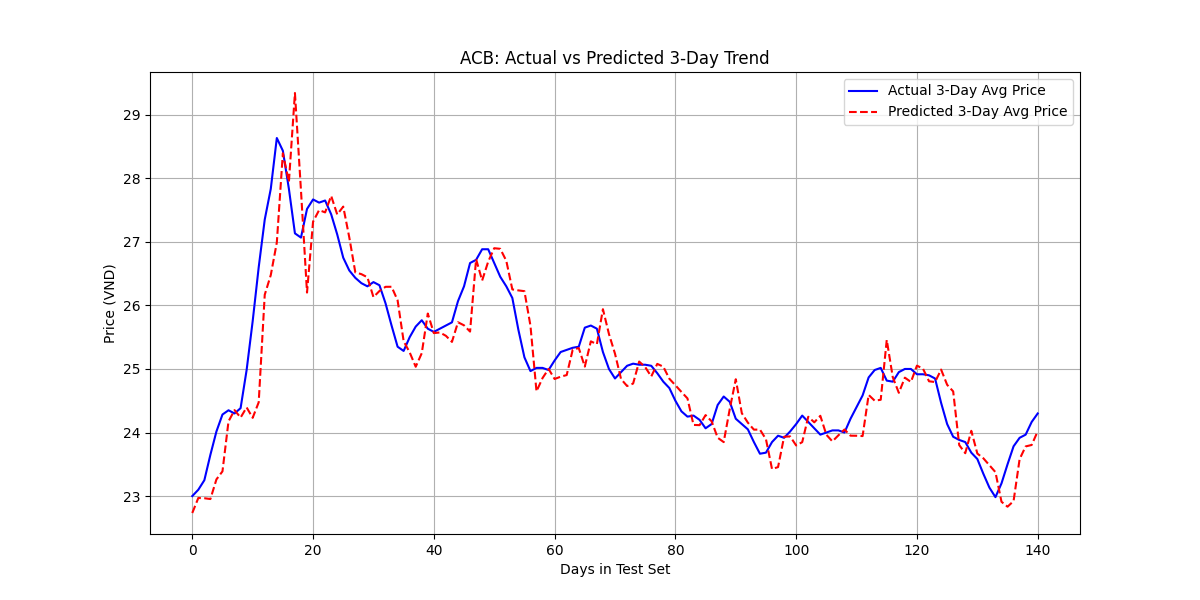

--------------------------------------------------------------------------------


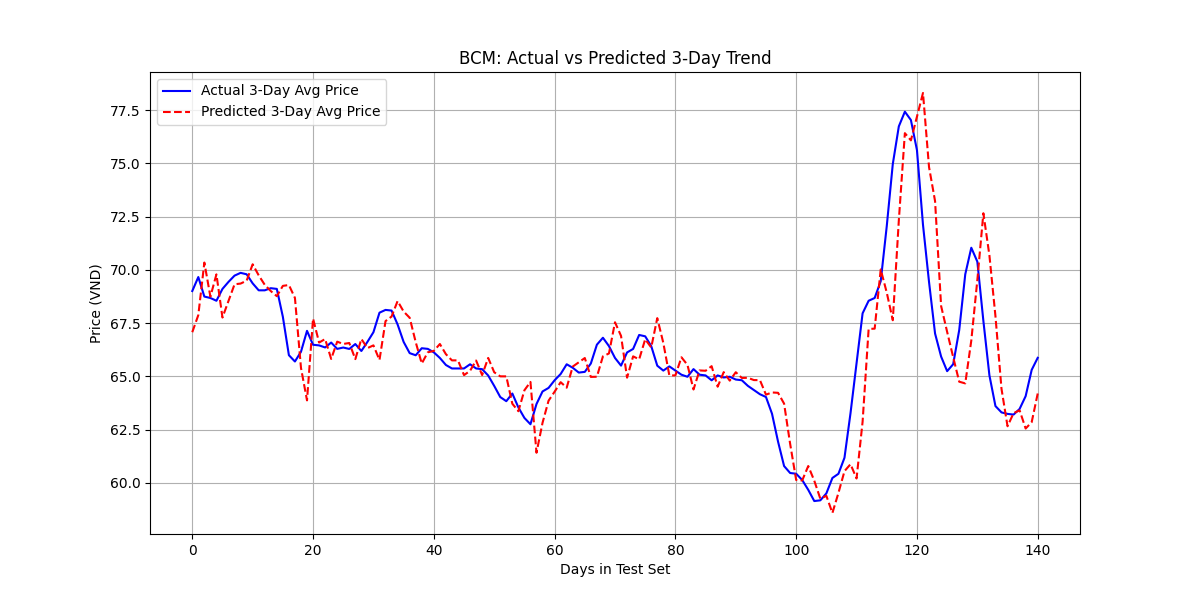

--------------------------------------------------------------------------------


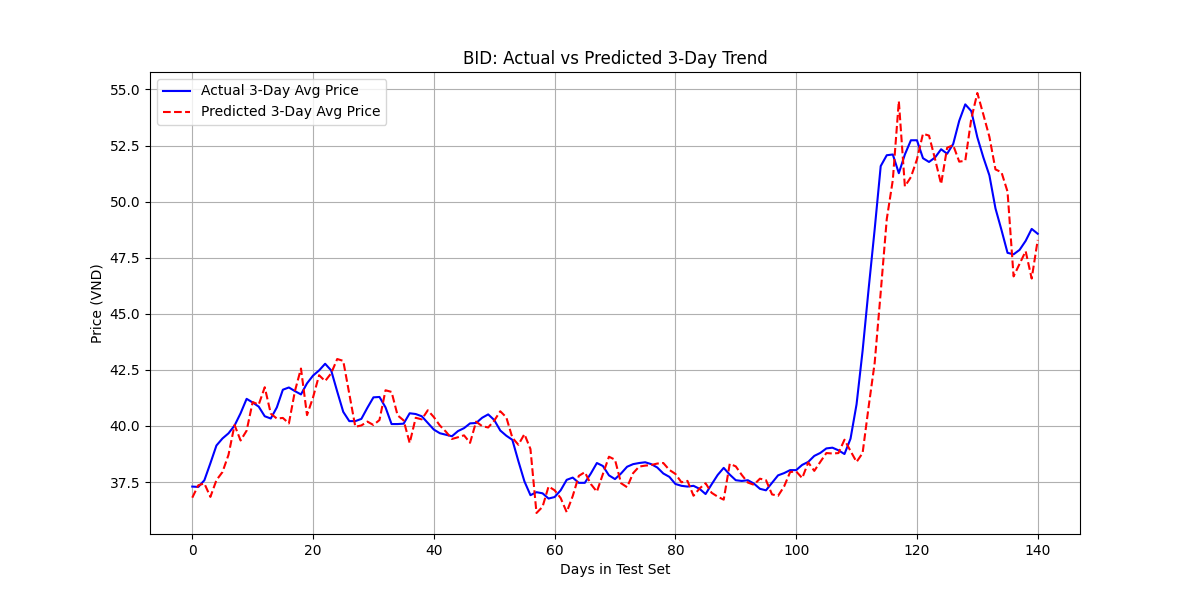

--------------------------------------------------------------------------------


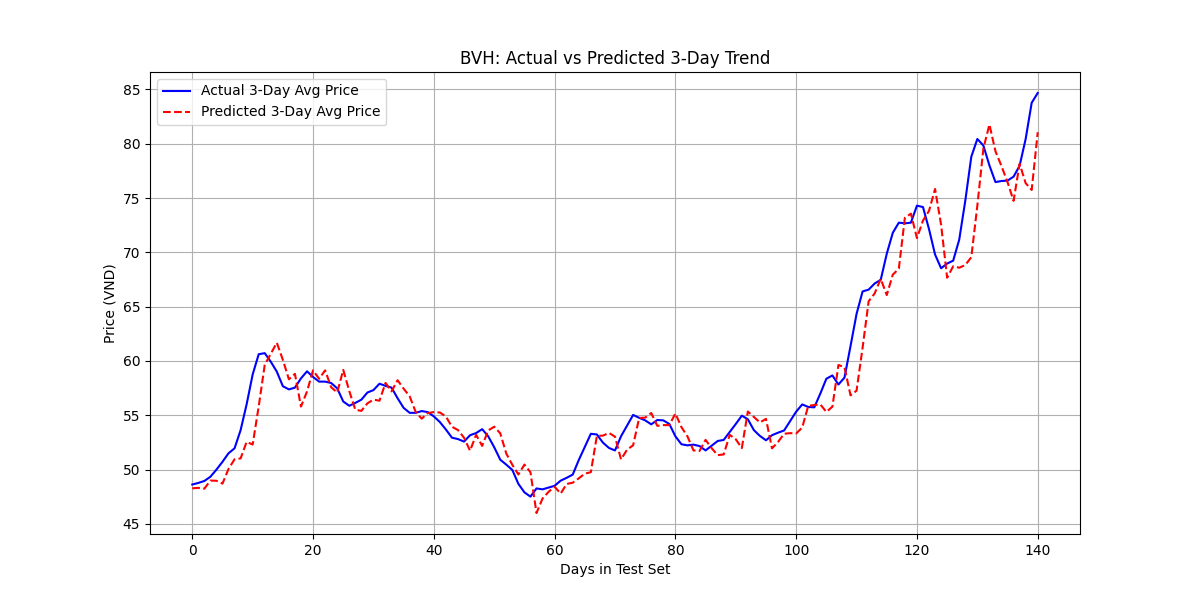

--------------------------------------------------------------------------------


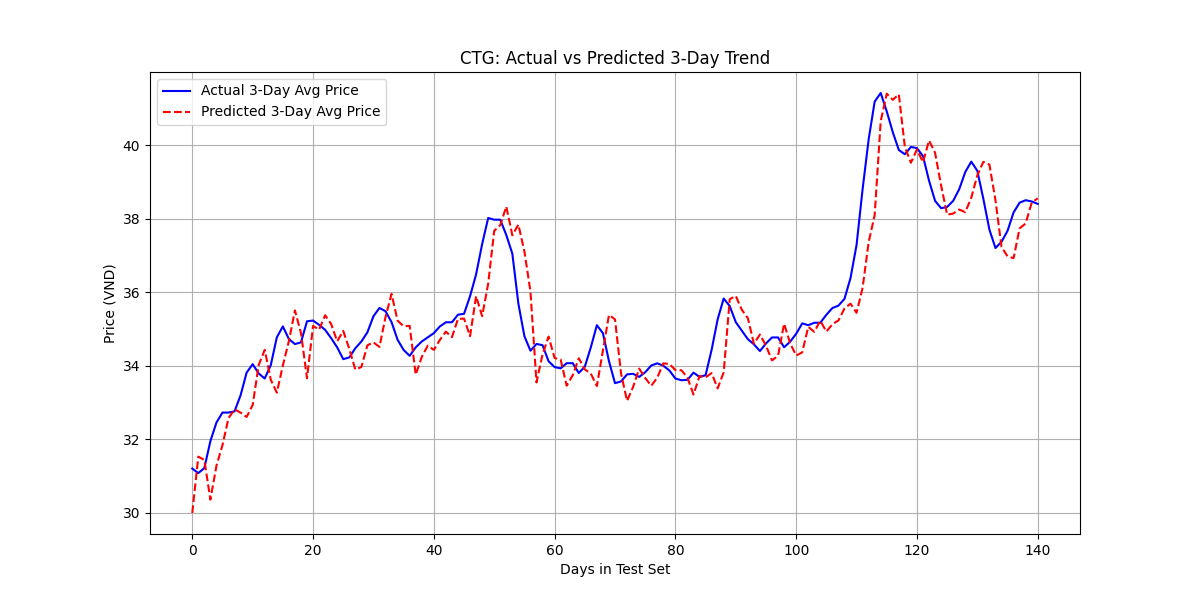

--------------------------------------------------------------------------------


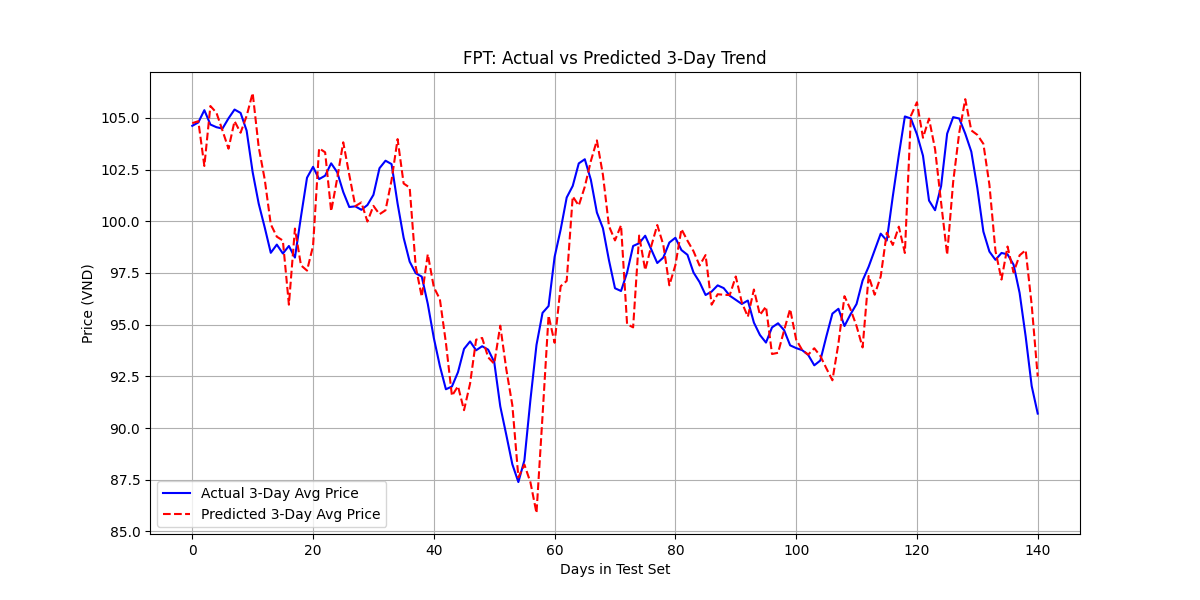

--------------------------------------------------------------------------------


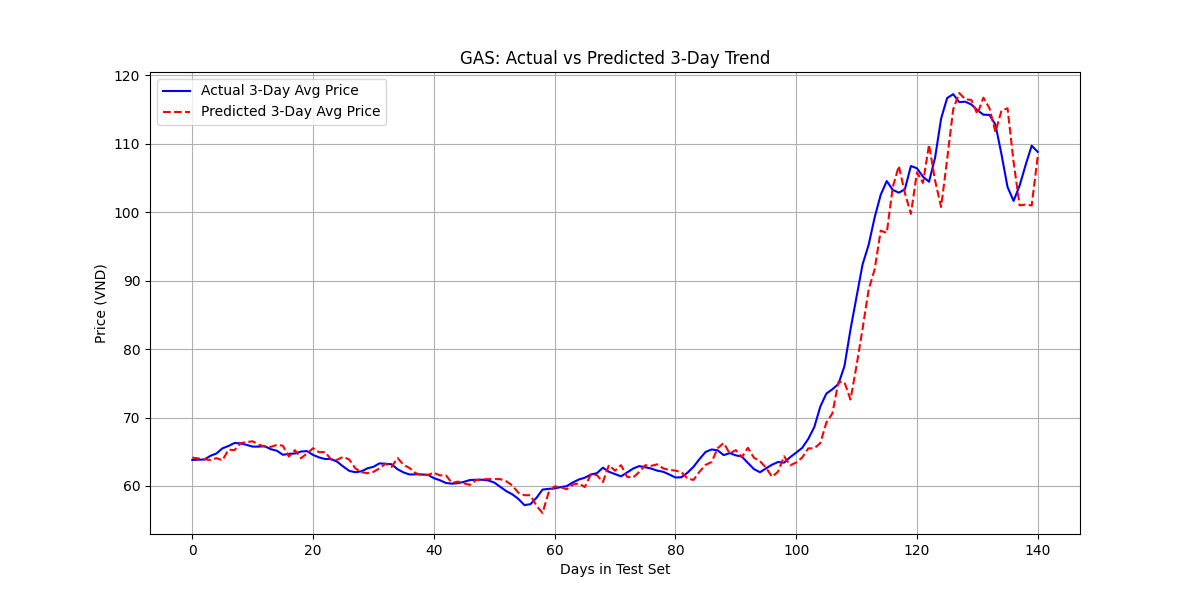

--------------------------------------------------------------------------------


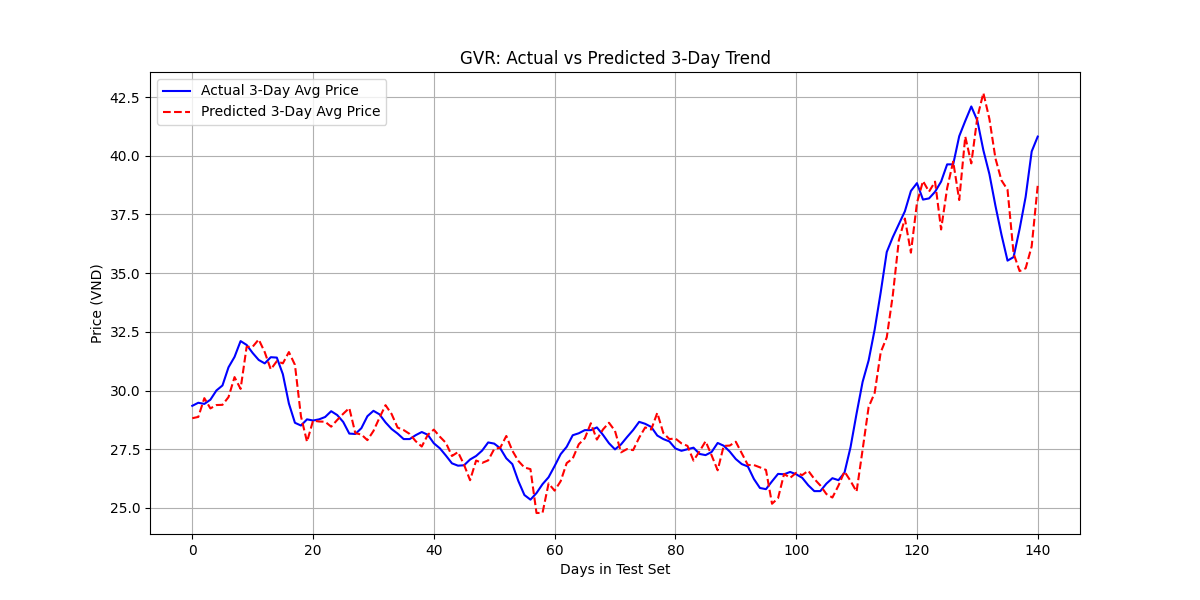

--------------------------------------------------------------------------------


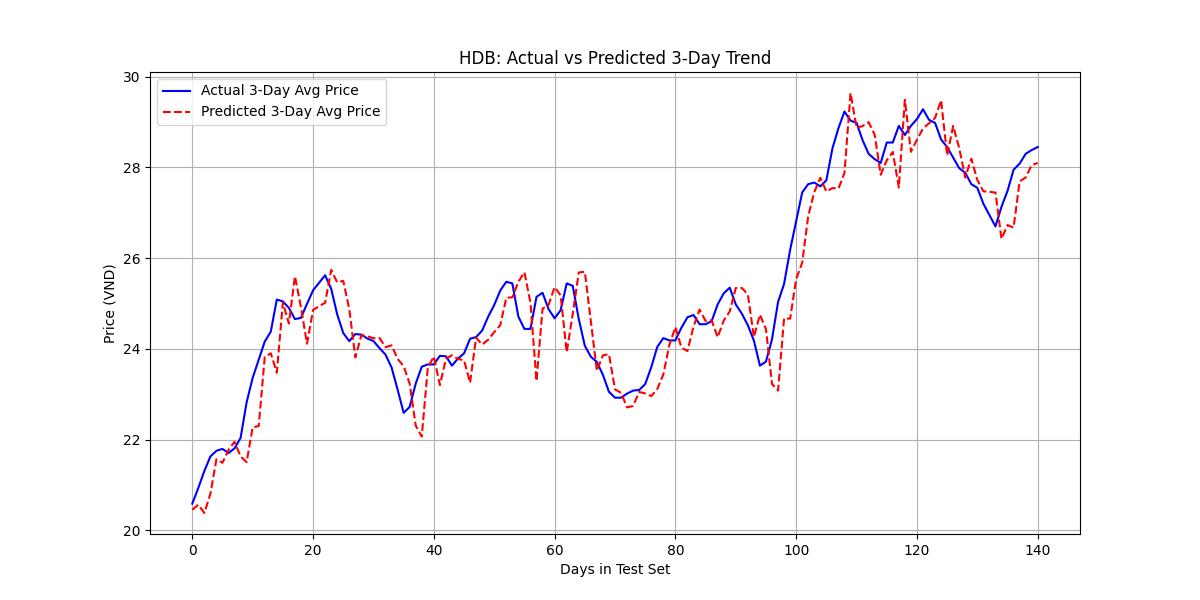

--------------------------------------------------------------------------------


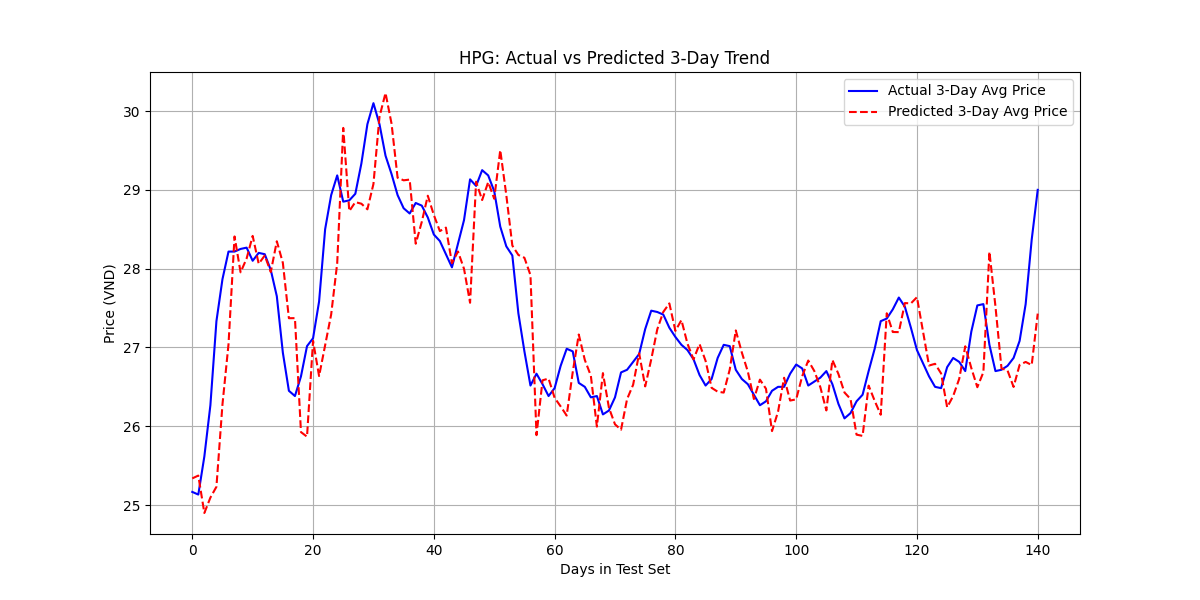

--------------------------------------------------------------------------------


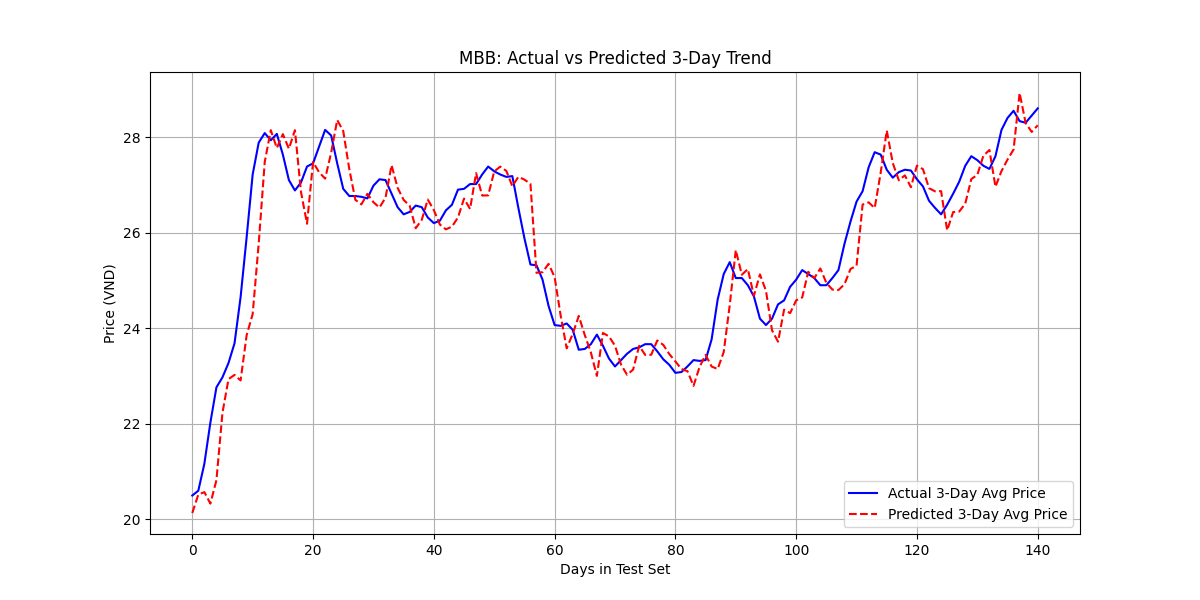

--------------------------------------------------------------------------------


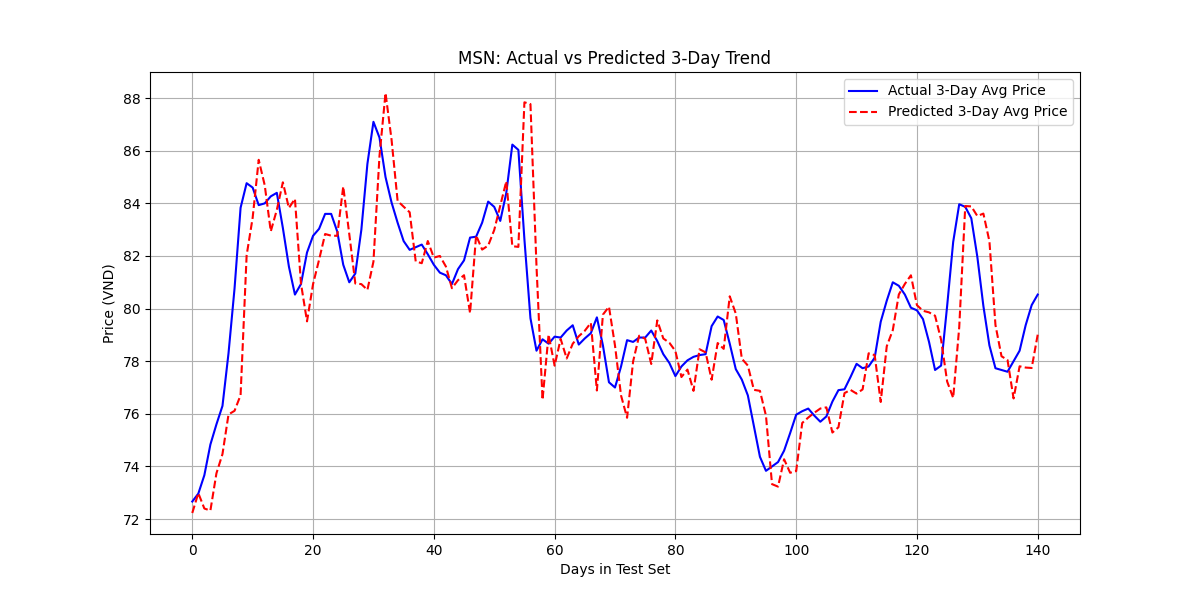

--------------------------------------------------------------------------------


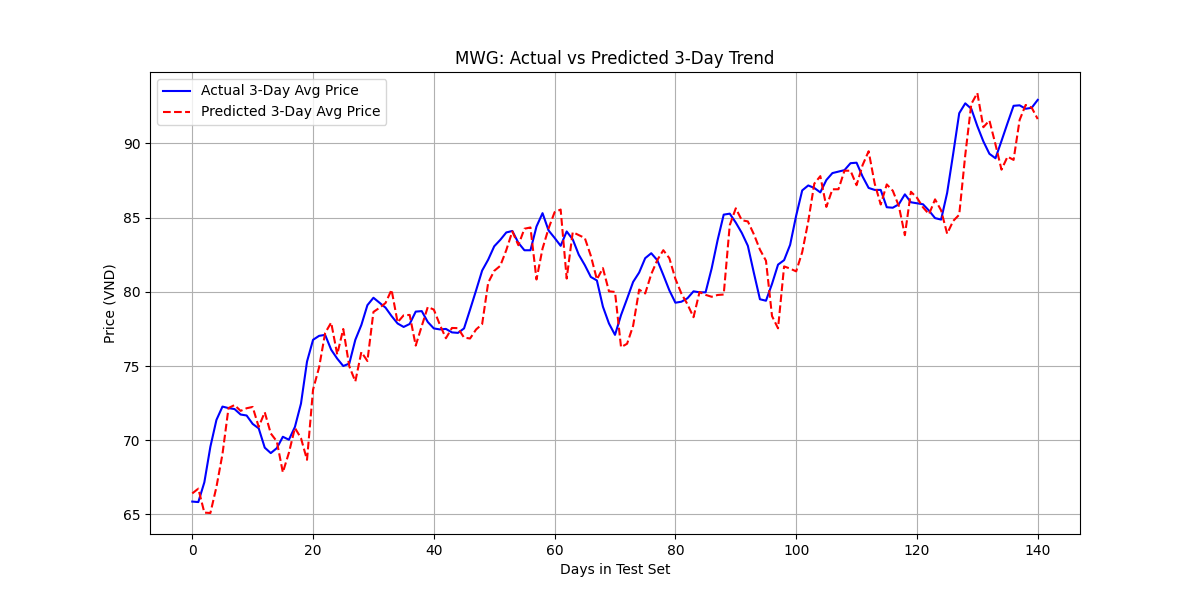

--------------------------------------------------------------------------------


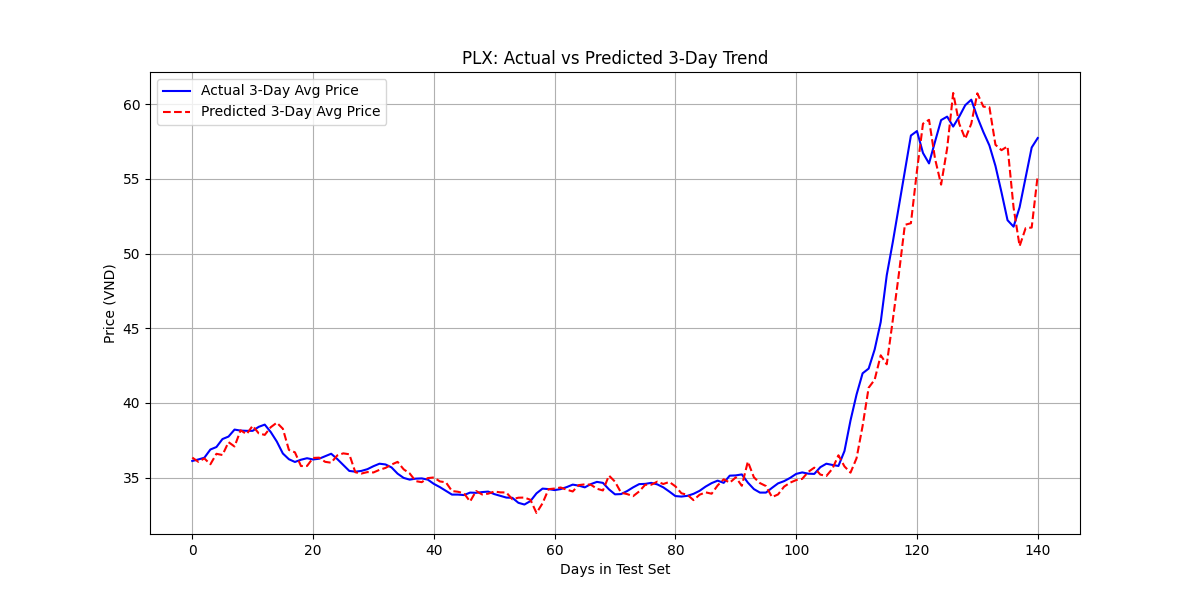

--------------------------------------------------------------------------------


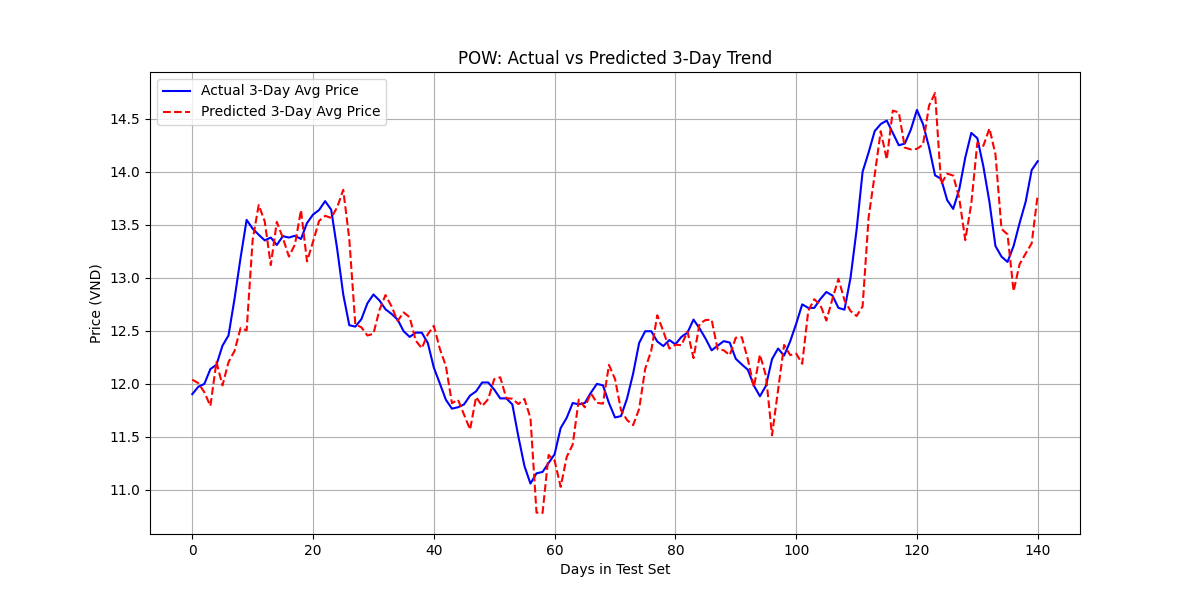

--------------------------------------------------------------------------------


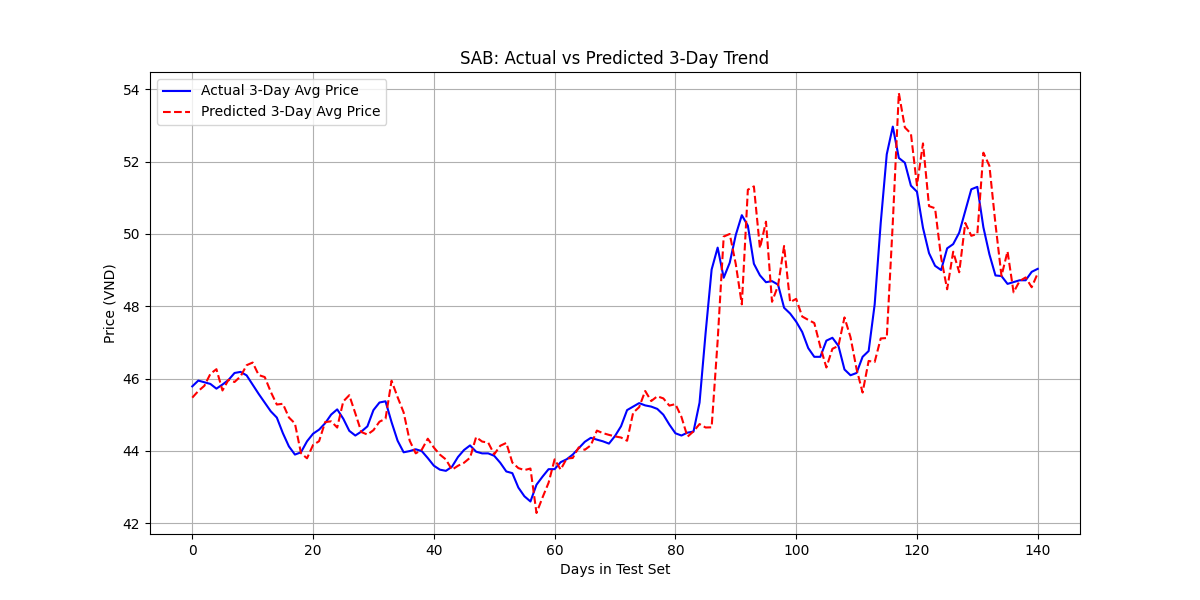

--------------------------------------------------------------------------------


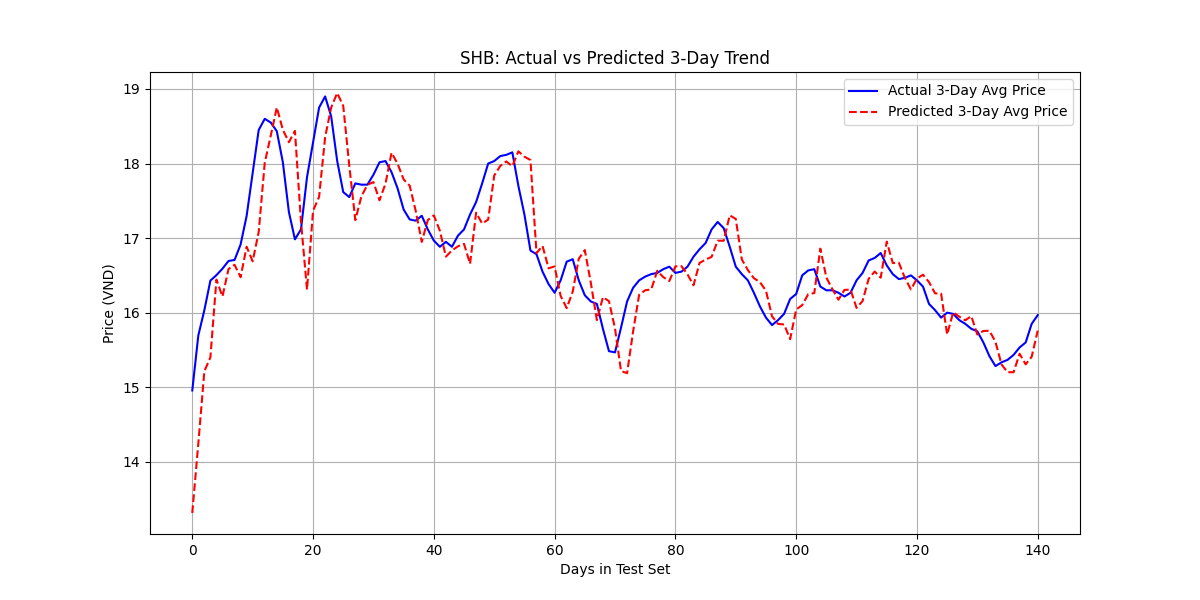

--------------------------------------------------------------------------------


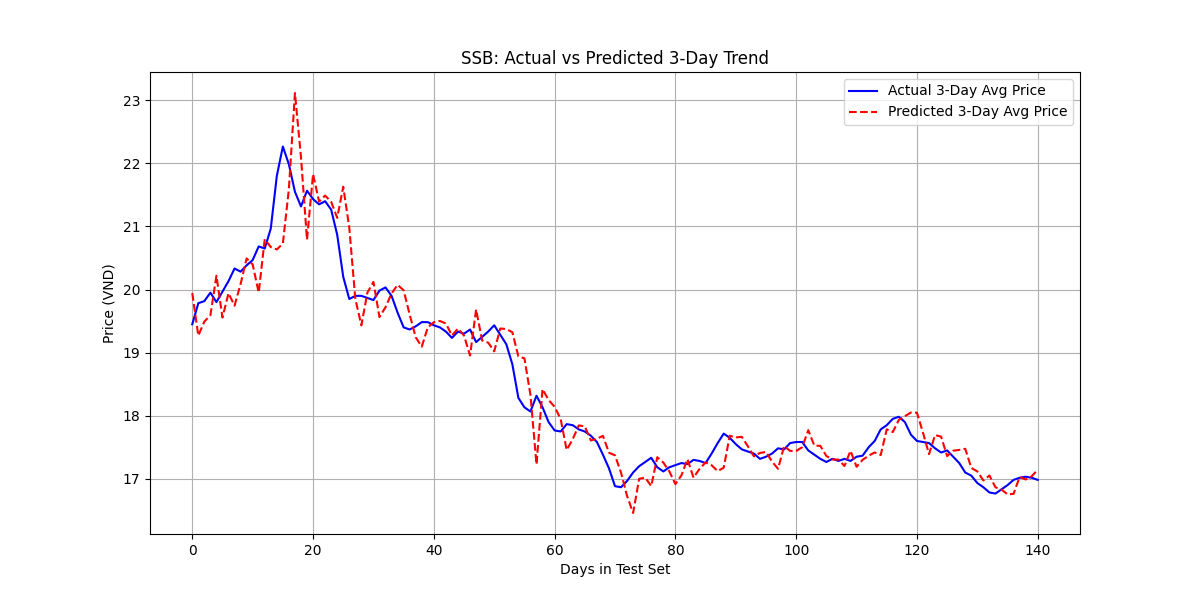

--------------------------------------------------------------------------------


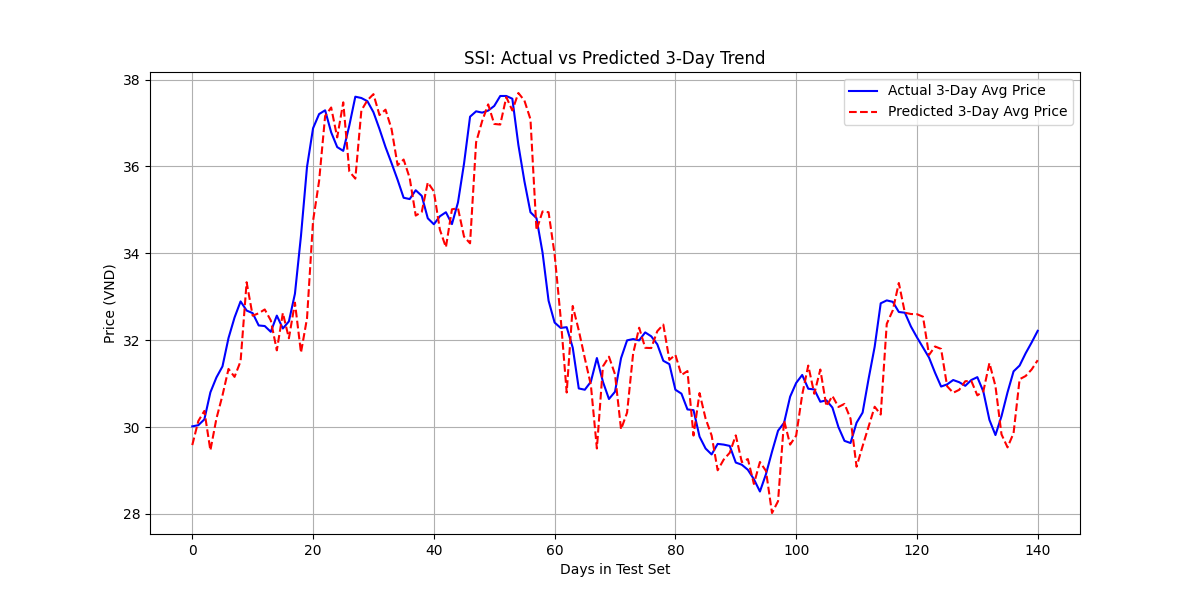

--------------------------------------------------------------------------------


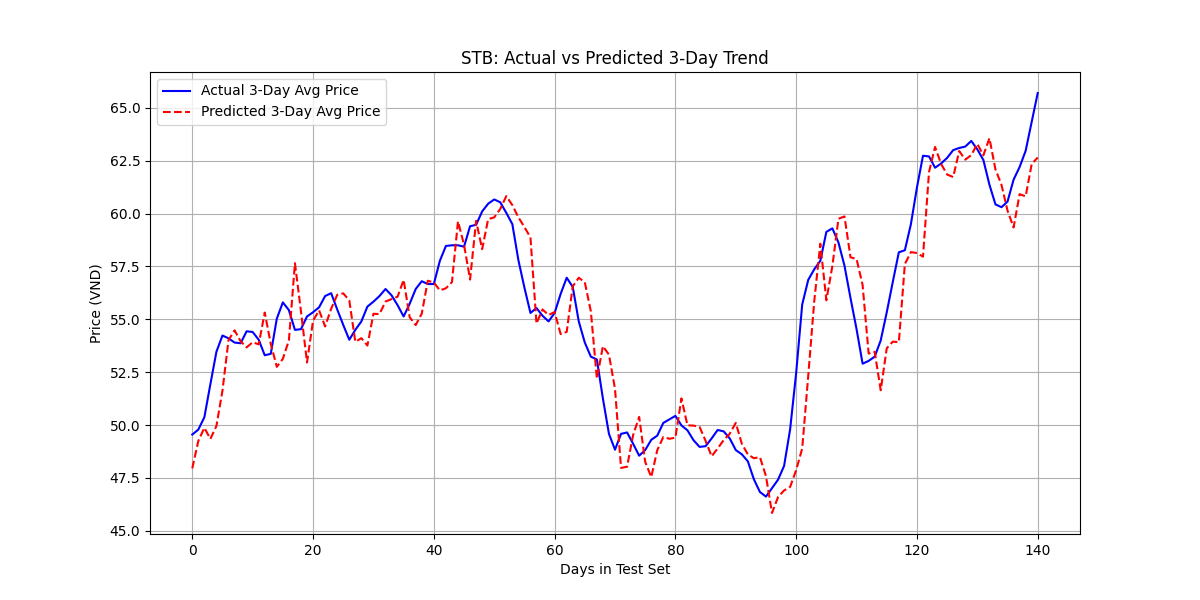

--------------------------------------------------------------------------------


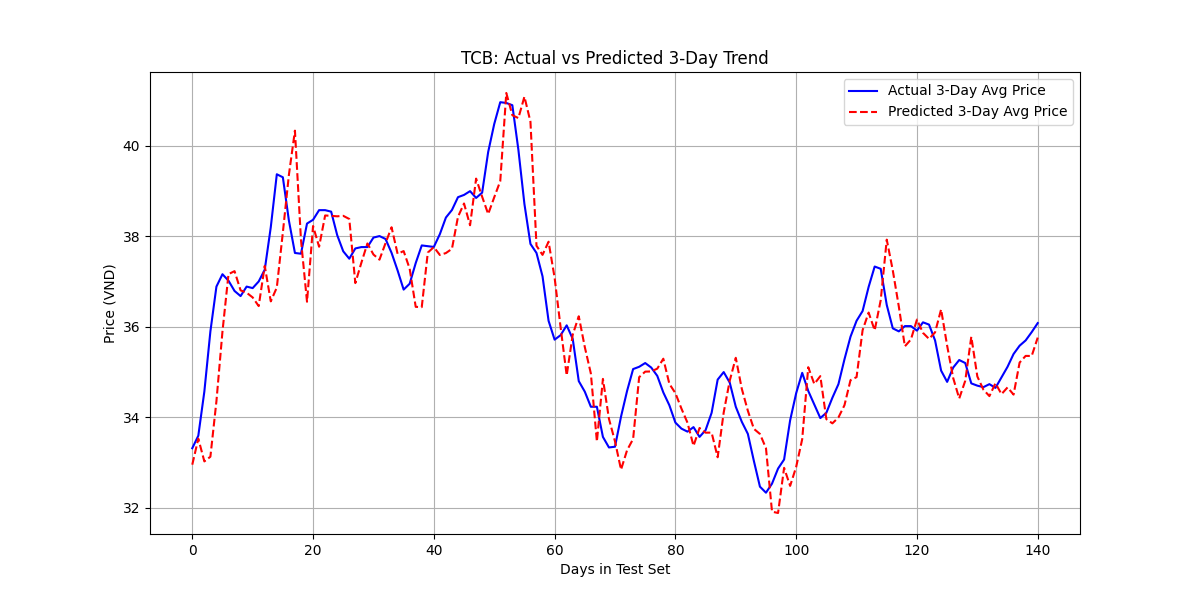

--------------------------------------------------------------------------------


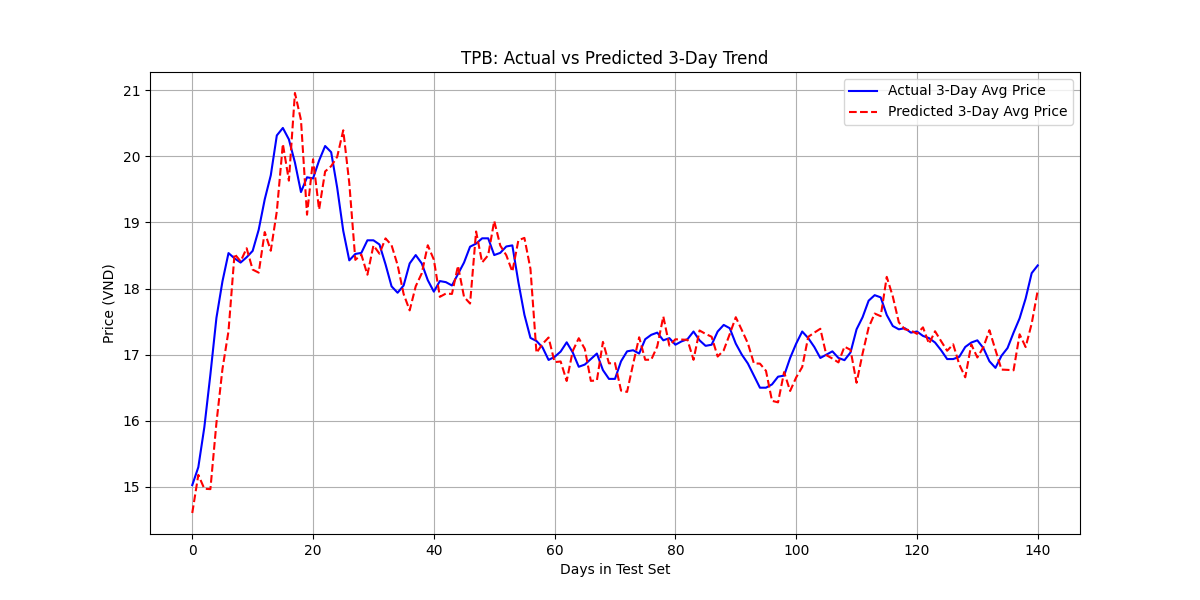

--------------------------------------------------------------------------------


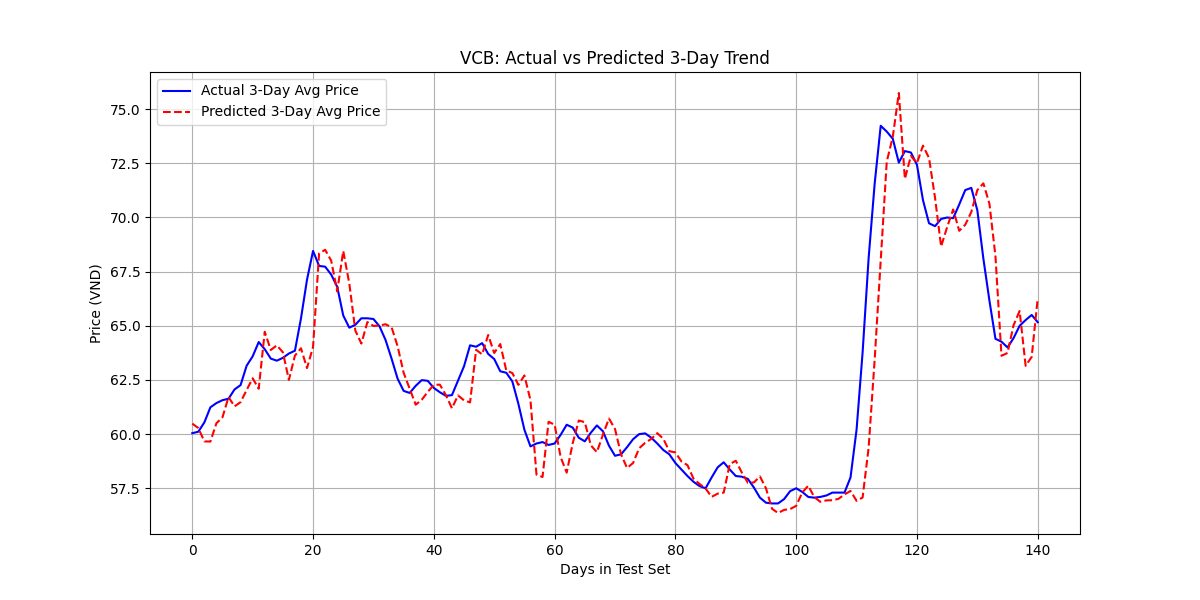

--------------------------------------------------------------------------------


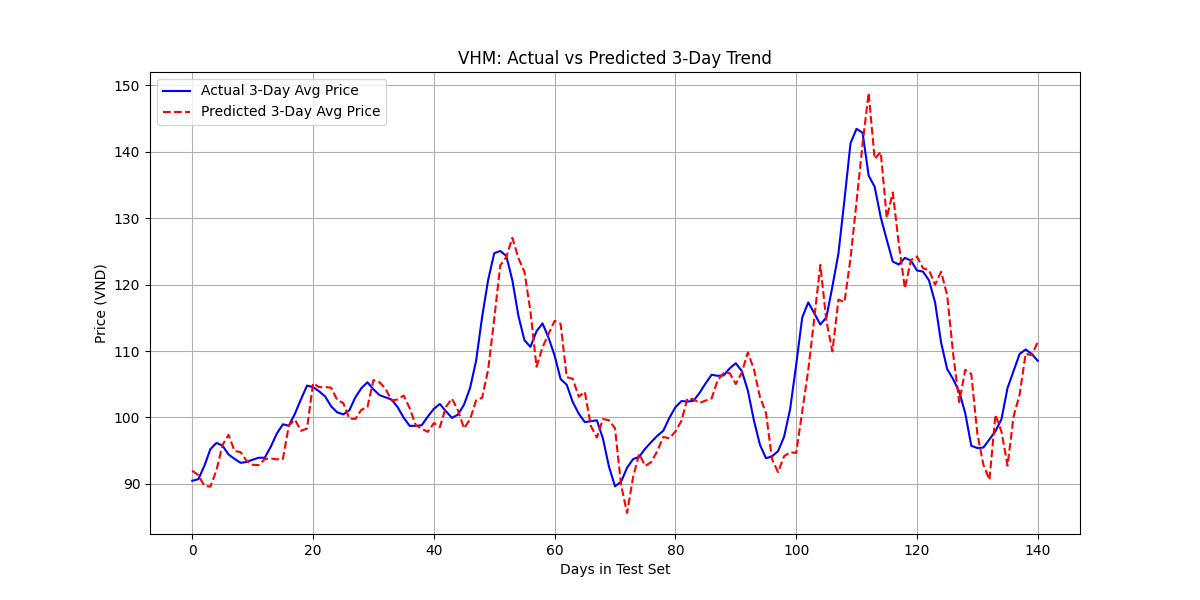

--------------------------------------------------------------------------------


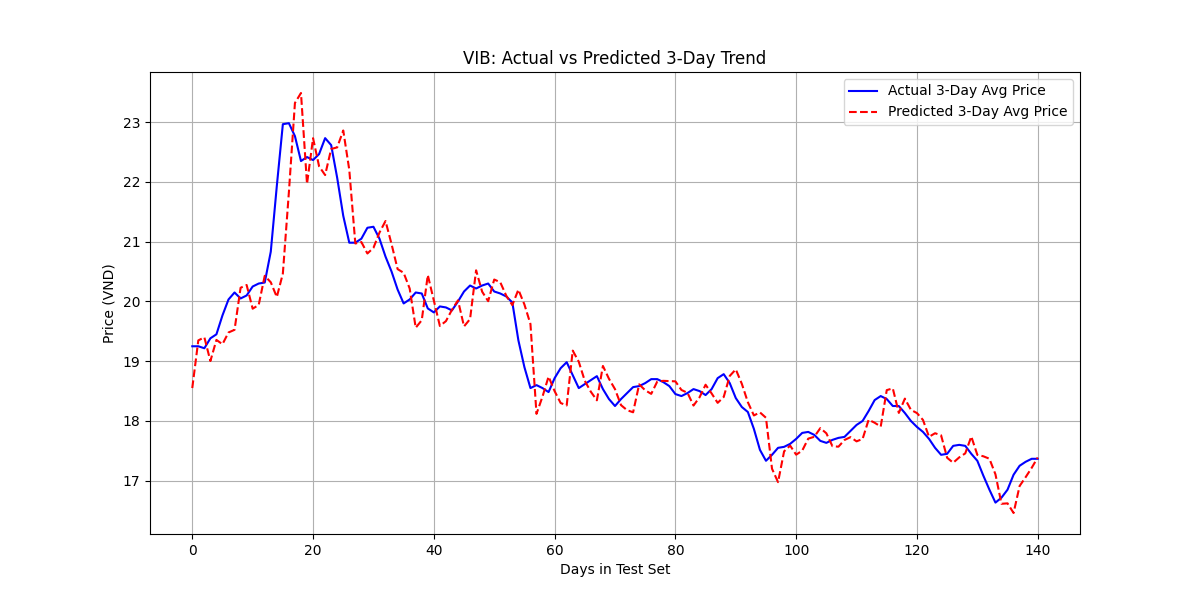

--------------------------------------------------------------------------------


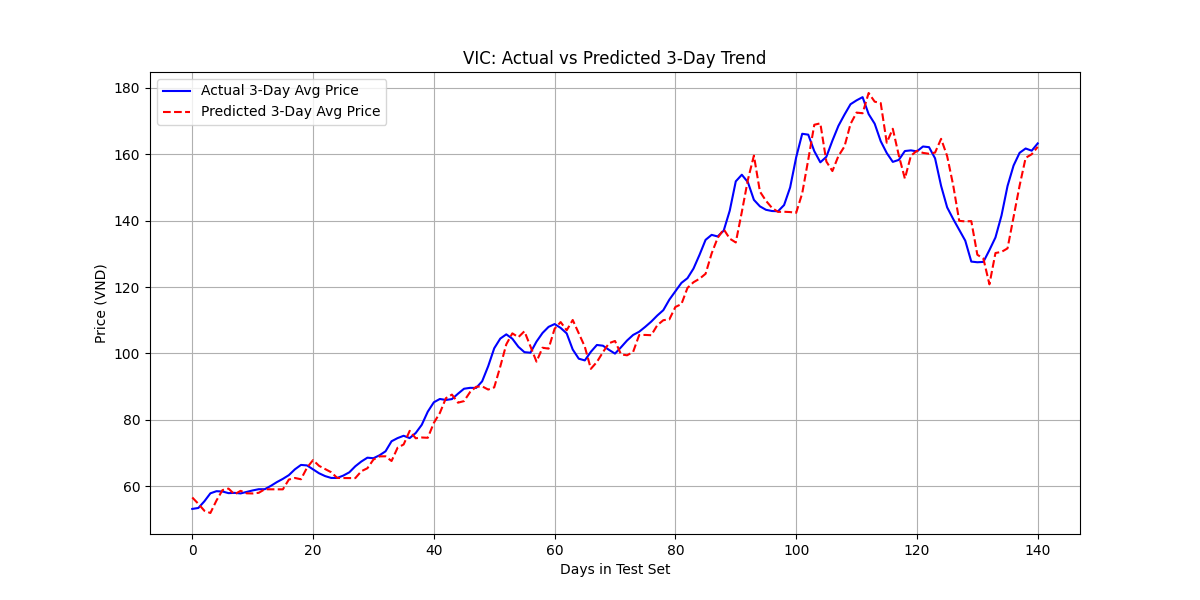

--------------------------------------------------------------------------------


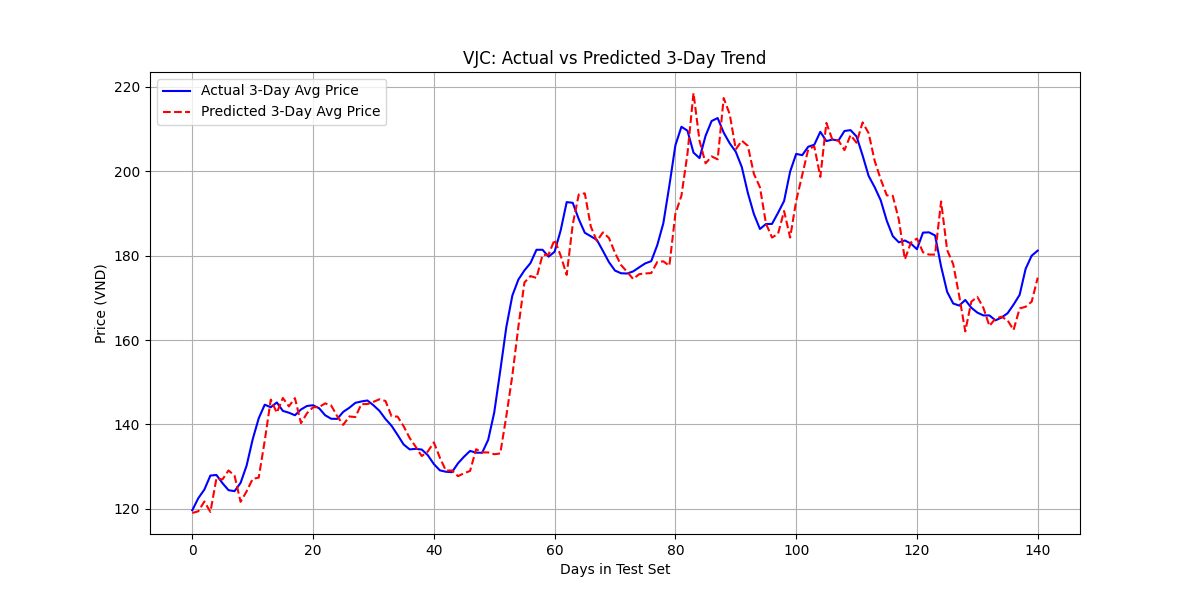

--------------------------------------------------------------------------------


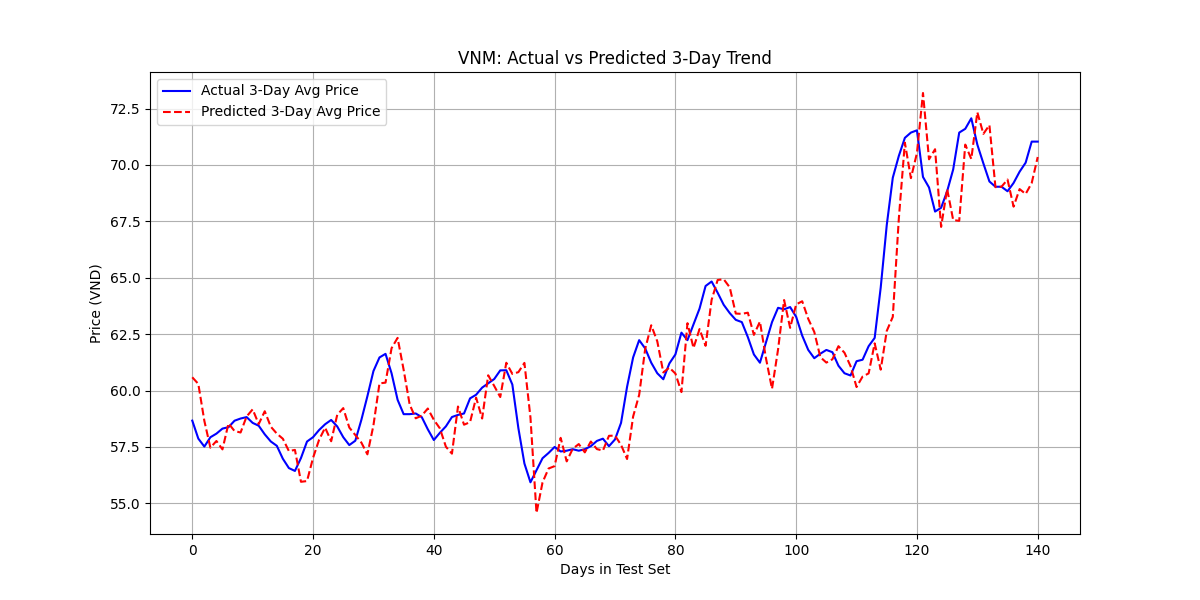

--------------------------------------------------------------------------------


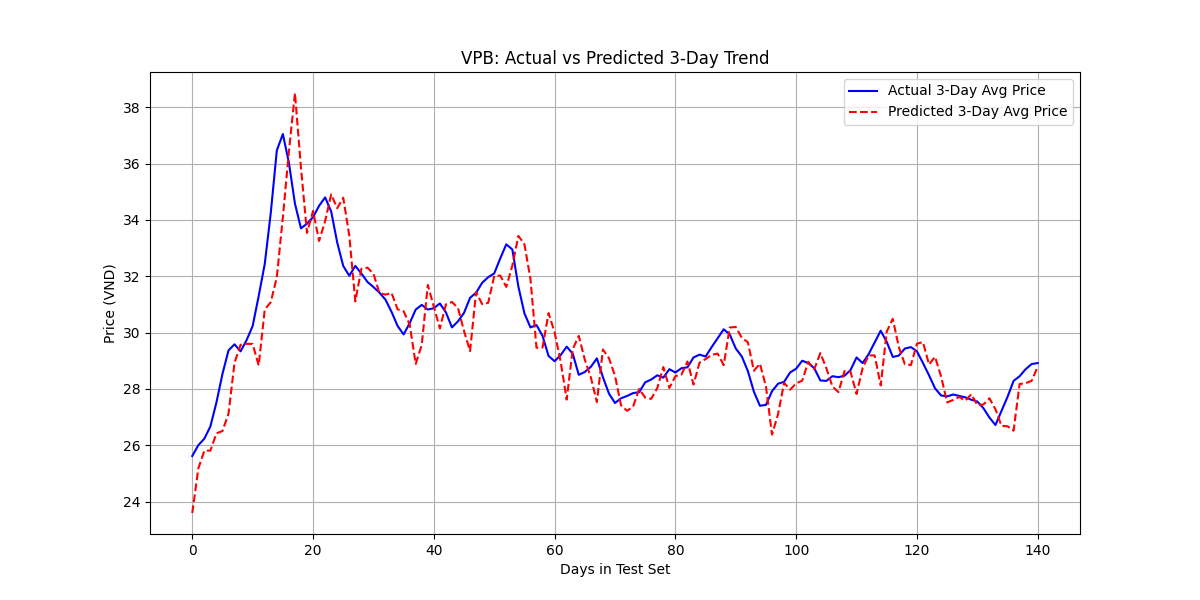

--------------------------------------------------------------------------------


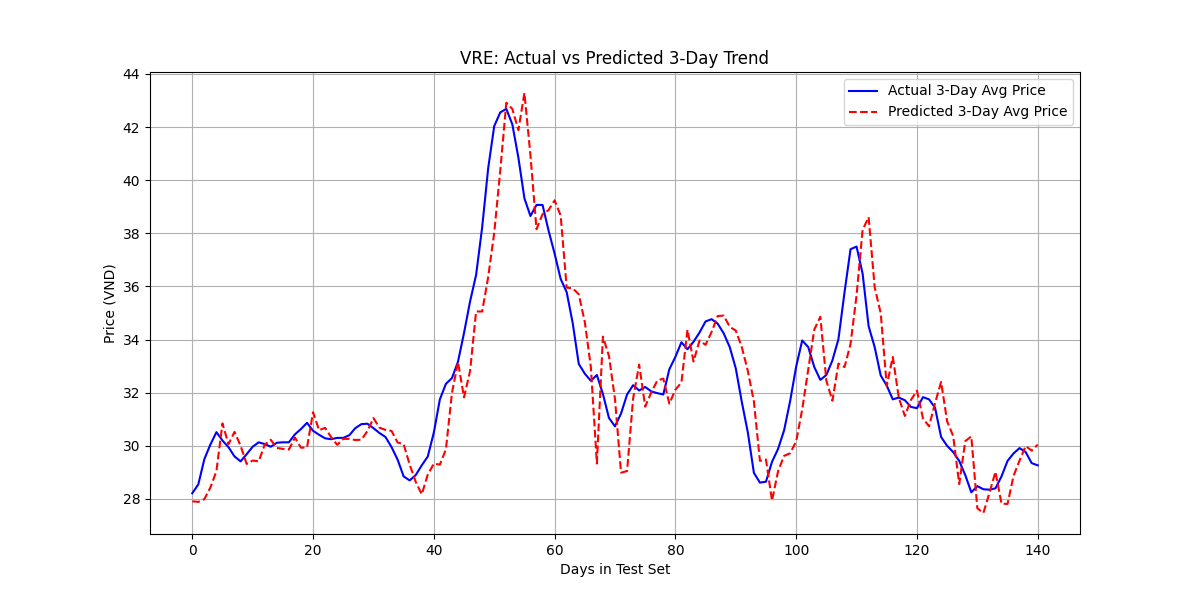

--------------------------------------------------------------------------------


In [10]:
import os
from IPython.display import Image, display

# The folder where your plots are saved
plot_dir = "/kaggle/working/VN30_Trend_Plots"

# Get a list of all PNG files in the folder and sort them alphabetically
image_files = sorted([f for f in os.listdir(plot_dir) if f.endswith('.png')])

print(f"Found {len(image_files)} plots. Displaying them now...\n")

# Loop through and display each image
for img_name in image_files:
    img_path = os.path.join(plot_dir, img_name)
    display(Image(filename=img_path))
    print("-" * 80) # Just a visual separator line